In [40]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [41]:
# Paramètres
J = 1.0
kB = 1.0 #Constante de Boltzmann
Tc = 2.269  # Température de Curie
L = 64 #Taille du réseau


In [42]:
#Initialisation d'une configuration aléatoire de N spins valant soit -1 soit 1

def initialise(L):
    return np.random.choice([-1, 1], size=(L, L))


In [43]:
# Calcul de la variation d'énergie associée au retournement d'un spin 

@njit
def delta_energie(spins, i, j, h):
    L = spins.shape[0]
    S = spins[i, j]
    v = (
        spins[(i+1)%L, j] + spins[(i-1)%L, j] +
        spins[i, (j+1)%L] + spins[i, (j-1)%L]
    )
    return 2* S * (J * v + h)


In [44]:
# Fonction qui fait un pas de Monte - Carlo (retournement de N spins)
@njit
def metropolis_pas(spins, T, h):
    L = spins.shape[0]

    for k in range(L * L):
    # On se donne un spin aléatoire i,j dans la configuration.
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

    # Appel de la fonction delta_energie

        dE = delta_energie(spins, i, j, h)

    # Condition de retournement


        if dE <= 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] *= -1

In [45]:
# Fonction qui retourne l'aimantation (moyenne des spins)
@njit
def magnetisation(spins):
    return np.mean(spins)

In [46]:
# Fonction qui calcule l'énergie totale du système 
@njit
def energie(spins, h):
    L = spins.shape[0]
    E = 0.0
    for i in range(L):
        for j in range(L):
            S = spins[i, j]
            v = spins[(i+1)%L, j] + spins[i, (j+1)%L]
    # On ajoute la contribution du spin (i,j)
            E += -J * S * v - h * S
    
    return E 

In [47]:
# On effectue un grand nombre de pas de Monte -Carlo

def simulation(L, T, h, n_min=5000, n_max=10000, interval=10):
    # On fixe une configuration initiale.
    spins = initialise(L)

    # On fait un grand nombre de pas de Monte - Carlo pour se rapprocher de l'équilibre
    for k in range(n_min):
        metropolis_pas(spins, T, h) 

    #Initialisation des listes permettant de stocker l'aimantation et l'énergie
    M_vals = []
    E_vals = []
    
    for k in range(n_max):
        for l in range(interval): #On ne prend que des valeurs par pas de 10
            metropolis_pas(spins, T, h) 
        #On ajoute les valeurs 
        M_vals.append(magnetisation(spins))
        E_vals.append(energie(spins, h))

    M_vals = np.array(M_vals)
    E_vals = np.array(E_vals)

    

    #Aimantation
    M_eq = np.mean(np.abs(M_vals))
    #Susceptibilité
    chi = 1 / T * (np.mean(M_vals**2) - np.mean(M_vals)**2)
    #Chaleur spécifique
    C = 1 / T**2 * (np.mean(E_vals**2) - np.mean(E_vals)**2)

    return M_eq, chi, C

h =  0
h =  1
h =  2
h =  3
h =  4


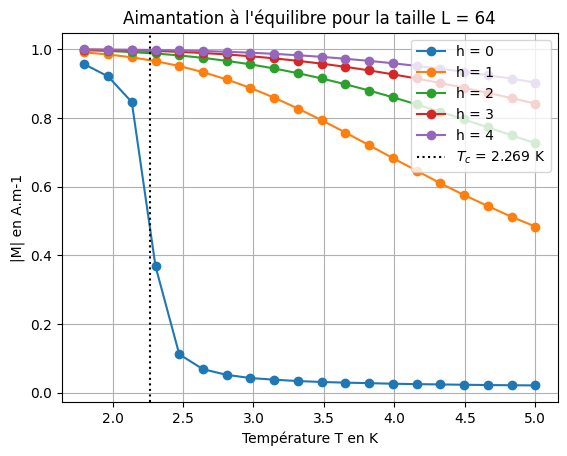

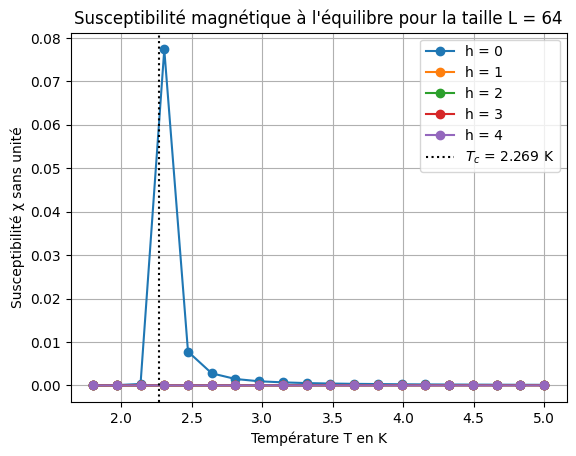

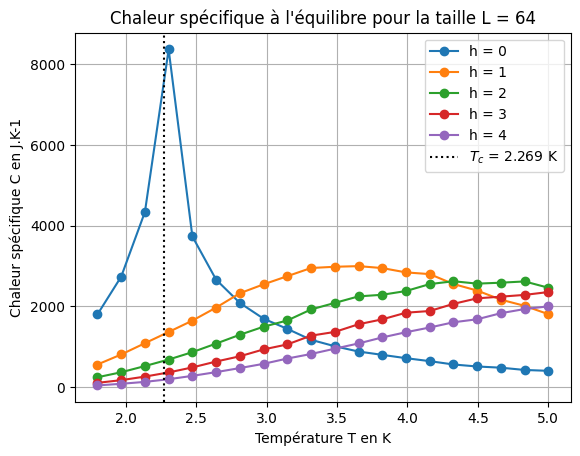

In [48]:
#Simulation

np.random.seed(0)

#Température
T_list = np.linspace(1.8, 5, 20)

#Champs magnétiques
h_list = [0,1,2,3,4]

M_eq_list = []
chi_list = []
C_list = []

for b in h_list :
    print("h = ",b) 
    for T in T_list:
        M_eq, chi, C = simulation(L, T, b)
        M_eq_list.append(M_eq)
        chi_list.append(chi)
        C_list.append(C)

M_eq_list = np.array(M_eq_list)


#Aimantation
plt.figure()
plt.plot(T_list, M_eq_list[0:20], "o-", label="h = 0")
plt.plot(T_list, M_eq_list[20:40], "o-", label="h = 1")
plt.plot(T_list, M_eq_list[40:60], "o-", label="h = 2")
plt.plot(T_list, M_eq_list[60:80], "o-", label="h = 3")
plt.plot(T_list, M_eq_list[80:100], "o-", label="h = 4")
plt.axvline(Tc, color="k", ls=":", label=r"$T_c$ = 2.269 K")
plt.xlabel("Température T en K")
plt.ylabel("|M| en A.m-1")
plt.title(f"Aimantation à l'équilibre pour la taille L = {L}")
plt.legend(loc = "upper right")
plt.grid()
plt.show()


#Susceptibilité
plt.figure()
plt.plot(T_list, chi_list[0:20], "o-", label="h = 0")
plt.plot(T_list, chi_list[20:40], "o-", label="h = 1")
plt.plot(T_list, chi_list[40:60], "o-", label="h = 2")
plt.plot(T_list, chi_list[60:80], "o-", label="h = 3")
plt.plot(T_list, chi_list[80:100], "o-", label="h = 4")
plt.axvline(Tc, color="k", ls=":", label=r"$T_c$ = 2.269 K")
plt.xlabel("Température T en K")
plt.ylabel("Susceptibilité χ sans unité")
plt.title(f"Susceptibilité magnétique à l'équilibre pour la taille L = {L}")
plt.legend(loc = "upper right")
plt.grid()
plt.show()



#Chaleur spécifique
plt.figure()
plt.plot(T_list, C_list[0:20], "o-", label="h = 0")
plt.plot(T_list, C_list[20:40], "o-", label="h = 1")
plt.plot(T_list, C_list[40:60], "o-", label="h = 2")
plt.plot(T_list, C_list[60:80], "o-", label="h = 3")
plt.plot(T_list, C_list[80:100], "o-", label="h = 4")
plt.axvline(Tc, color="k", ls=":", label=r"$T_c$ = 2.269 K")
plt.xlabel("Température T en K")
plt.ylabel("Chaleur spécifique C en J.K-1")
plt.title(f"Chaleur spécifique à l'équilibre pour la taille L = {L}")
plt.legend(loc = "upper right")
plt.grid()
plt.show()